In [3]:
from dotenv import load_dotenv

load_dotenv()

True

In [4]:
from langchain_openai import ChatOpenAI


query = "인프런에는 어떤 강의가 있나요?"

llm = ChatOpenAI(model="gpt-5-nano")

llm.invoke(query)

# LangGraph에서 메세지 히스토리를 다룰 때는 문자열보다
# 아래처럼 메시지 객체 리스트로 넣는 방식이 더 명확
# from langchain_core.messages import HumanMessage
# llm.invoke([HumanMessage(content=query)])


AIMessage(content='인프런은 주로 기술/직무 스킬에 초점을 맞춘 온라인 강의 플랫폼이에요. 다양한 주제의 강의가 있어서 관심 분야에 맞춰 고를 수 있습니다.\n\n주요 카테고리 예시\n- 프로그래밍 언어: Python, Java, JavaScript, C/C++, Kotlin, Swift 등\n- 웹 개발: 프런트엔드(React, Vue, Angular 등), 백엔드(Node.js, Spring, Django 등)\n- 모바일 개발: Android, iOS, React Native, Flutter\n- 데이터/인공지능: 데이터 분석, 머신러닝, 딥러닝, SQL/데이터베이스\n- 클라우드/데브옵스: AWS, GCP, Azure, Docker, Kubernetes, CI/CD\n- 데이터베이스 및 데이터 엔지니어링\n- 게임 개발: Unity, Unreal 등\n- 디자인/UI/UX: 피그마 등 디자인 도구와 실무 가이드\n- 도구 및 협업: Git/GitHub, Jira 등 협업 도구, 커리어 코칭\n- 취업/포트폴리오/면접 대비\n\n강의 형식\n- 영상 강의 + 실습 코드\n- 과제나 프로젝트 포함 여부\n- 강의 자료(PDF, 코드 예제) 제공 여부\n- 일부 강의는 무료이거나 체험판이 있고, 대부분은 개별 구매로 수강합니다. 때때로 할인이나 쿠폰도 있습니다.\n\n강의 선택 팁\n- 목표 분야와 역량 수준 확인: 예를 들어 프런트엔드 입문, 파이썬 데이터 분석, AWS 기초 등\n- 커리큘럼 구성 체크: 주제 순서, 실습 여부, 프로젝트 규모\n- 강사 및 후기 확인: 강사 경력, 수강생 리뷰 점수와 코멘트\n- 가격·환불 정책 확인: 무료 강의 여부, 환불 규정은 강의 페이지에서 확인\n- 샘플 강의나 예고편으로 난이도 파악\n\n원하시면 구체적으로 관심 분야나 목표(예: "JavaScript 기초에서 React로 확장", "Python으로 데이터 분석 시작하기", "AWS 기초부터 실무까지")를 알려주세요. 예산, 선호하는 난이도, 한국

| 요소 | 핵심 개념 | 정확한 설명 |
|---|---|---|
| **State** | 현재 Agent의 상태 | 그래프 실행 중 Node들이 공유하고 갱신하는 데이터 |
| **Node** | Agent가 수행하는 작업 | State를 입력받아 작업을 수행하고 업데이트를 반환하는 실행 단위 |
| **Edge** | Node들의 관계 | 한 Node가 끝난 뒤 다음에 실행할 Node를 고정하는 연결 |
| **Conditional Edge** | 조건에 따른 Node들의 관계 | State를 기준으로 다음에 실행할 Node를 동적으로 선택하는 연결 |

In [5]:
from typing import Annotated
from typing_extensions import TypedDict

from langgraph.graph.message import add_messages
from langchain_core.messages import AnyMessage

class AgentState(TypedDict):
    messages: Annotated[list[AnyMessage], add_messages]

In [6]:
from langgraph.graph import StateGraph

graph_builder = StateGraph(AgentState)

In [7]:
# def generate(state: AgentState) -> AgentState:
def generate(state: AgentState):
    messages = state['messages']
    ai_message = llm.invoke(messages)
    return {'messages': [ai_message]}

In [8]:
graph_builder.add_node('generate', generate)

In [9]:
from langgraph.graph import START, END

graph_builder.add_edge(START, 'generate')
graph_builder.add_edge('generate', END)

In [10]:
graph = graph_builder.compile()

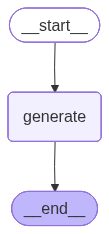

In [11]:
from IPython.display import display, Image

display(Image(graph.get_graph().draw_mermaid_png()))

In [ ]:
from langchain_core.messages import HumanMessage

initial_state = {'messages': [HumanMessage(query)]}
# 더 명확한 형태
# initial_state = {'messages': [HumanMessage(content=query)]}
graph.invoke(initial_state)

{'messages': [HumanMessage(content='인프런에는 어떤 강의가 있나요?', additional_kwargs={}, response_metadata={}, id='28e769b1-2016-4990-be79-315b022a707f'),
  AIMessage(content='인프런은 IT/개발 분야를 중심으로 매우 다양한 강의를 제공합니다. 대표적인 카테고리와 예시를 정리해 드릴게요.\n\n주요 카테고리\n- 프론트엔드 개발: HTML/CSS, 자바스크립트 기본, React, Vue, Next.js 등\n- 백엔드 개발: Node.js, NestJS, Spring, Django, Laravel 등\n- 모바일 개발: Android(TKotlin/Java), iOS(Swift)\n- 데이터 사이언스/AI: 파이썬 기초, 데이터 분석, 머신러닝/딥러닝 입문 등\n- 클라우드/데브옵스/인프라: AWS, Docker, Kubernetes, CI/CD\n- 데이터베이스/SQL, 데이터 파이프라인\n- 게임 개발, 보안, 네트워킹 등 IT 직무 관련 주제\n- 도구·스택별 강의: TypeScript, GraphQL, Git, 테스트 자동화, 프레임워크별 실무 가이드 등\n- 커리어/취업 대비: 이력서/포트폴리오 작성, 면접 대비, 실무 스킬 가이드\n\n강의 특성\n- 난이도 분류: 초급·중급·고급 등으로 구분\n- 언어/자막: 한국어 강의 및 자막 제공 여부가 흔히 표시됩니다\n- 실무 중심 프로젝트, 샘플 코딩과 과제 포함 여부\n- 무료 강의와 유료 강의 병행\n\n실시간 카탈로그 확인 방법\n- 인프런 홈페이지에 접속: inflearn.com\n- 상단 메뉴의 카테고리나 검색창으로 관심 분야 선택\n- 강의 목록에서 난이도, 가격(무료/유료), 언어 자막, 강의 시간 등을 필터링\n- 수강생 수, 평점, 신규 업데이트 여부를 참고\n\n도움이 필요하면 구체적으로 말씀해 주세요\n- 예: “React 프론트엔드 강의를 찾고 싶어요.” 또는 “파이